# **Simulating Epileptic Neuronal Dynamics Using the LIF Model**

This notebook implements a simple network of Leaky Integrate-and-Fire (LIF) neurons to simulate and compare the general dynamics of three conditions in networks of neurons: normal, epileptic and treated epileptic.

I examine how network parameters such as synaptic strength, input current, and refractory periods influence neuronal firing patterns and synchrony.

## **Simulation Parameters**


I first simulate the spiking activity in a network of 30 neurons using the Leaky Integrate-and-Fire (LIF) model over a period of 3000 ms, under three network conditions: normal, epileptic and treated epileptic.

Each neuron receives a combination of external input current, random noise and excitatory synaptic input from other neurons based on a sparse connectivity matrix. The epileptic network differs from the normal one by having:

- a higher input current

- stronger synaptic weights

- a shorter refractory period

- slightly depolarized resting and threshold potentials

To simulate treatment, a third condition reduces the synaptic gain and slightly lowers the input current.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

In [2]:
# Simulation settings
T = 3000       # total time in ms
dt = 1         # time step in ms
time = np.arange(0, T, dt)
n_neurons = 30

# LIF parameters
V_rest = -65
V_th = -50
V_reset = -70
tau_m = 20
R_m = 10
ref_period = 5
ref_epileptic = 2

# Inputs
I_normal = 2.2
I_epileptic = 2.8
noise_std = 0.3

# Sparse random excitatory connectivity (no self-connections)
np.random.seed(42)
W = np.random.rand(n_neurons, n_neurons) < 0.2
W = W.astype(float)
np.fill_diagonal(W, 0)

W_normal = W * 0.5
W_epileptic = W * 1.5

In [3]:
def simulate_lif(I_input, ref_period, add_noise=False, connectivity=None, syn_gain=1.0,
                 V_rest_override=None, V_th_override=None):

    local_V_rest = V_rest_override if V_rest_override is not None else V_rest
    local_V_th = V_th_override if V_th_override is not None else V_th

    # Initialise membrane potentials with small variability
    V = np.random.normal(V_rest, 1.0, size=(n_neurons,))[:, None] * np.ones((1, len(time)))
    spikes = np.zeros_like(V)               # Spike train matrix (neurons x time)
    ref_timer = np.zeros(n_neurons)         # Refractory counters for each neuron

    for t in range(1, len(time)):

        # Add small per-neuron fluctuation to input current
        if isinstance(I_input, (int, float)):
            I_input_perturbed = I_input + np.random.normal(0, 0.7, size=n_neurons)
        else:
            I_input_perturbed = I_input

        # Add random noise to each neuron's input
        if add_noise:
            noise = np.random.normal(0, noise_std, size=n_neurons)
        else:
            noise = 0

        input_current = I_input_perturbed + noise

        # Add synaptic input from other neurons
        if connectivity is not None and t > 1:
            syn_input = np.dot(connectivity, spikes[:, t - 1])  # sum of incoming spikes
            input_current += syn_gain * syn_input

        # Update membrane potential using LIF differential equation
        dV = (-(V[:, t - 1] - local_V_rest) + R_m * input_current) / tau_m
        V[:, t] = V[:, t - 1] + dt * dV

        # Refractory period
        V[ref_timer > 0, t] = V_reset
        ref_timer = np.maximum(0, ref_timer - dt)

        # Detect spikes
        spiking = V[:, t] >= local_V_th
        spikes[spiking, t] = 1
        V[spiking, t] = V_reset
        ref_timer[spiking] = ref_period

    return spikes

In [4]:
# NORMAL
spikes_normal_net = simulate_lif(
    I_input=I_normal,
    ref_period=ref_period,
    add_noise=True,
    connectivity=W_normal)


# EPILEPTIC
V_rest_epileptic = -62
V_th_epileptic = -52

spikes_epileptic_net = simulate_lif(
    I_input=I_epileptic,
    ref_period=ref_epileptic,
    add_noise=True,
    connectivity=W_epileptic,
    syn_gain=3,
    V_rest_override=V_rest_epileptic,
    V_th_override=V_th_epileptic
)


# TREATMENT
I_treated = 2.4
treated_syn_gain = 0.6

spikes_treated = simulate_lif(
    I_input=I_treated,
    ref_period=ref_epileptic,
    add_noise=True,
    connectivity=W_epileptic,
    syn_gain=treated_syn_gain
)

For all conditions, I generate raster plots and ISI histograms to visualise and compare firing activity and temporal patterns.

In [5]:
# Plot raster
def plot_raster(spikes, title, figsize=(13, 3)):
    plt.figure(figsize=figsize)
    for n in range(n_neurons):
        spike_times = time[spikes[n] == 1]
        plt.vlines(spike_times, n + 0.5, n + 1.5)
    plt.xlabel('Time (ms)')
    plt.ylabel('Neuron')
    plt.title(title)
    plt.ylim(0.5, n_neurons + 0.5)
    plt.tight_layout()
    plt.show()

# Plot ISI
def plot_isi(spikes, neuron_id, title, figsize=(5, 3)):
    plt.figure(figsize=figsize)
    spike_times = time[spikes[neuron_id] == 1]
    if len(spike_times) < 2:
        print(f"No ISI data for neuron {neuron_id}")
        return
    isis = np.diff(spike_times)
    plt.hist(isis, bins=20, color='purple', edgecolor='black')
    plt.title(title)
    plt.xlabel('ISI (ms)')
    plt.ylabel('Count')
    plt.show()

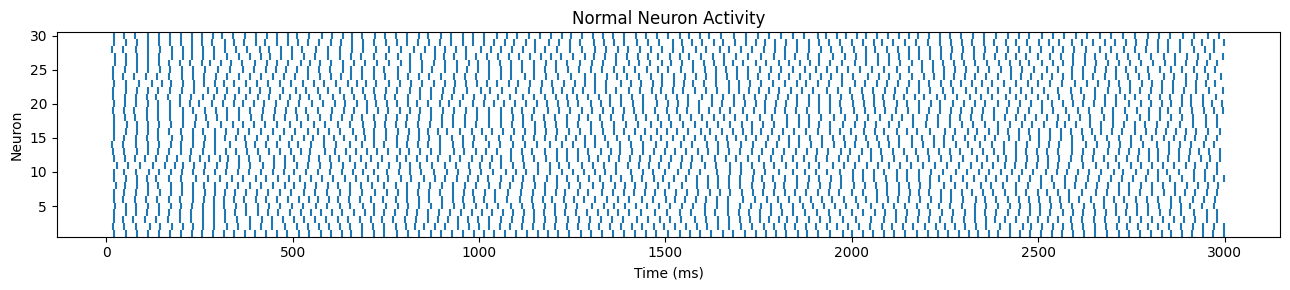

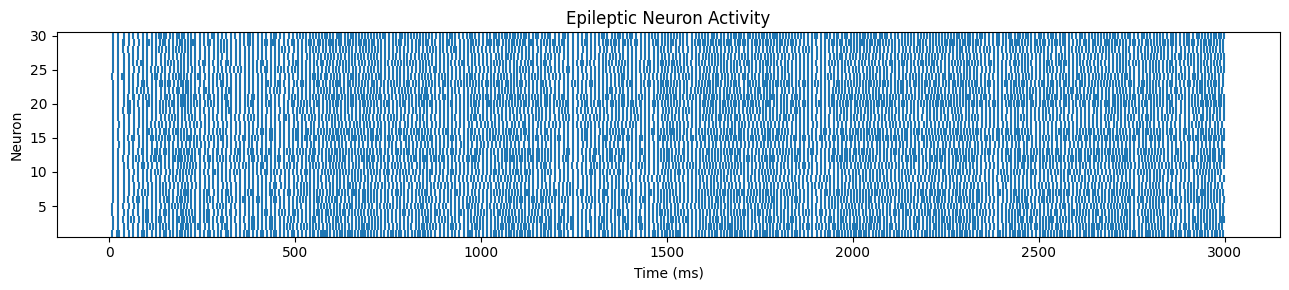

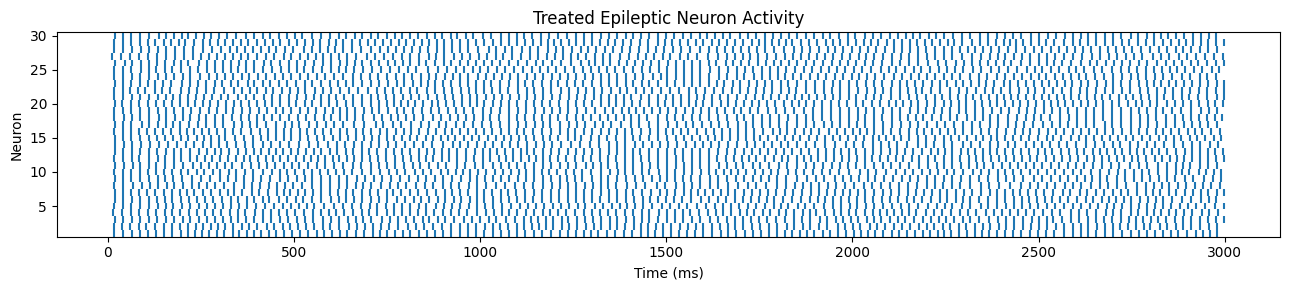

In [6]:
# Plot rasters
plot_raster(spikes_normal_net, "Normal Neuron Activity")
plot_raster(spikes_epileptic_net, "Epileptic Neuron Activity")
plot_raster(spikes_treated, "Treated Epileptic Neuron Activity")

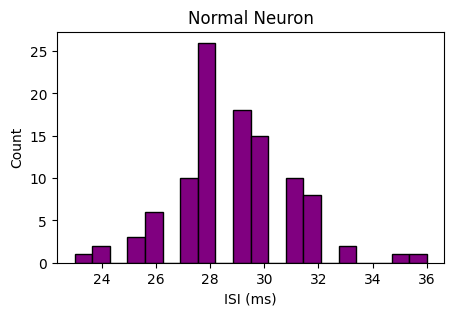

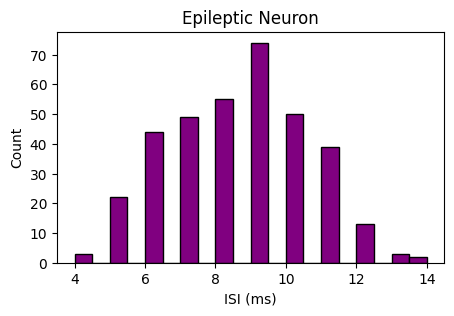

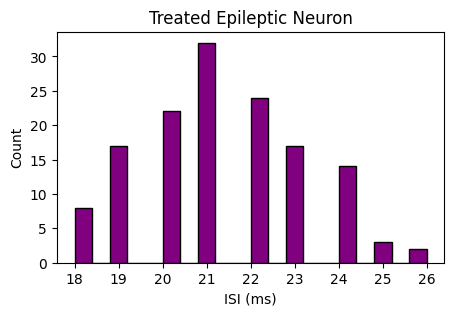

In [7]:
# Plot ISIs
plot_isi(spikes_normal_net, 0, "Normal Neuron")
plot_isi(spikes_epileptic_net, 0, "Epileptic Neuron")
plot_isi(spikes_treated, 0, "Treated Epileptic Neuron")

## **Firing Rate Analysis**

In this section I compute analyse firing rates of neurons under each condition.

1. The mean firing rate is computed, providing a single summary metric (in Hz) of the overall network excitability. This is visualised using a bar chart.

2. Histograms display the distribution of firing rates across individual neurons for each condition. They reveal how firing behaviour varies across the population, and how pathological or treated states affect this distribution.

Together, these visualisations help assess how the network’s excitability shifts between healthy, epileptic and treated states.

In [8]:
def mean_firing_rate(spikes, total_time_ms):
    total_spikes = np.sum(spikes)
    duration_s = total_time_ms / 1000
    rate_hz = total_spikes / (n_neurons * duration_s)
    return rate_hz

In [9]:
def plot_firing_rates(spikes_list, labels, total_time_ms):
    rates = [mean_firing_rate(s, total_time_ms) for s in spikes_list] # Compute mean firing rate for each condition

    plt.figure(figsize=(5, 4))
    bars = plt.bar(labels, rates, color=["skyblue", "salmon", "lightgreen"])
    plt.ylabel("Mean Firing Rate (Hz)")
    plt.title("Average Firing Rate per Condition")
    plt.ylim(0, max(rates) * 1.2)

    for bar, val in zip(bars, rates):
        plt.text(bar.get_x() + bar.get_width()/2, val + 0.2, f"{val:.2f}", ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

def neuron_firing_distribution(spikes_list, labels, total_time_ms):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

    colors = ["skyblue", "salmon", "lightgreen"]

    for ax, spikes, label, color in zip(axes, spikes_list, labels, colors):
        rates = np.sum(spikes, axis=1) / (total_time_ms / 1000)  # Compute individual neuron firing rates in Hz

        ax.hist(rates, bins=10, color=color, edgecolor='black')
        ax.set_title(f"{label}")
        ax.set_xlabel("Rate (Hz)")
        ax.set_xlim(0, max(rates)*1.2)
        ax.grid(True)

    axes[0].set_ylabel("Neuron Count")
    fig.suptitle("Firing Rate Distributions", fontsize=14)
    plt.tight_layout()
    plt.show()

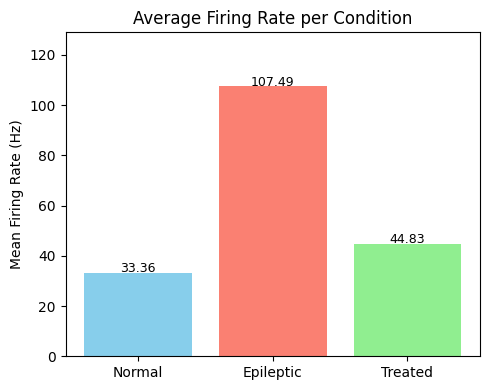

In [10]:
plot_firing_rates(
    [spikes_normal_net, spikes_epileptic_net, spikes_treated],
    ["Normal", "Epileptic", "Treated"],
    total_time_ms=T
)

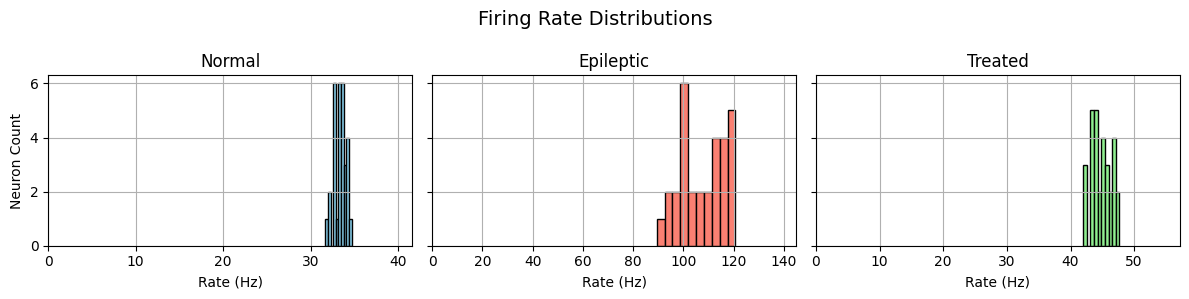

In [11]:
neuron_firing_distribution(
    [spikes_normal_net, spikes_epileptic_net, spikes_treated],
    ["Normal", "Epileptic", "Treated"],
    total_time_ms=T
)

## **Functional Connectivity via Spike Correlation**

This section evaluates functional connectivity across the neuronal networks by computing pairwise spike correlations. Using spike trains binned in short time windows, Pearson correlation coefficients are calculated between all neuron pairs. The resulting matrix is thus symmetric, and it is displayed as a heatmap for each condition.

Warmer colours indicate stronger positive correlations (high synchrony), while cooler tones reflect anti-correlation or independence.

In [12]:
def get_spike_correlation_matrix(spikes, bin_size=5):
    n_bins = len(time) // bin_size
    binned_spikes = np.zeros((n_neurons, n_bins))

    for i in range(n_neurons):
        for b in range(n_bins):
            binned_spikes[i, b] = np.sum(spikes[i, b * bin_size:(b + 1) * bin_size])

    return np.corrcoef(binned_spikes)

In [13]:
# Compute correlation matrices
corr_normal = get_spike_correlation_matrix(spikes_normal_net)
corr_epileptic = get_spike_correlation_matrix(spikes_epileptic_net)
corr_treated = get_spike_correlation_matrix(spikes_treated)

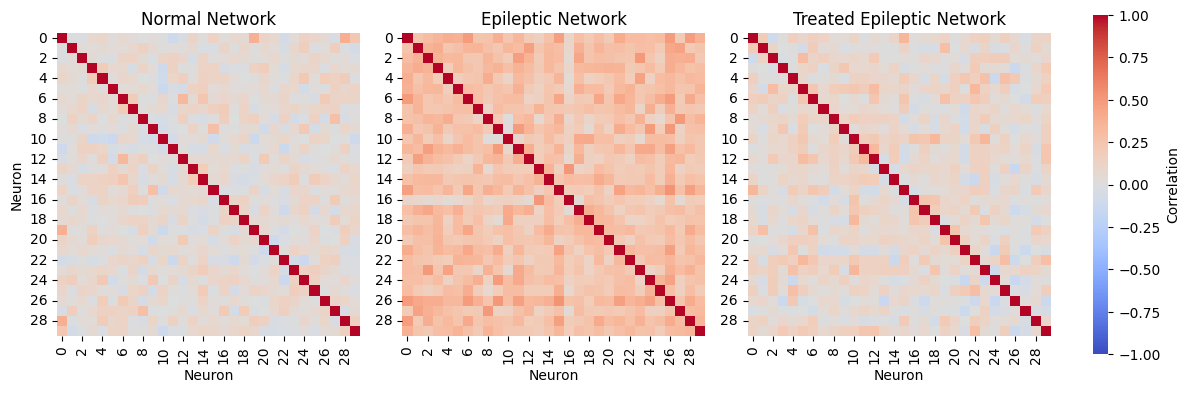

In [14]:
# Plot heatmaps
fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05])

axs = [plt.subplot(gs[i]) for i in range(3)]
cbar_ax = plt.subplot(gs[3])

sns.heatmap(corr_normal, cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=axs[0], cbar=False)
axs[0].set_title("Normal Network")
axs[0].set_xlabel("Neuron")
axs[0].set_ylabel("Neuron")

sns.heatmap(corr_epileptic, cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=axs[1], cbar=False)
axs[1].set_title("Epileptic Network")
axs[1].set_xlabel("Neuron")
axs[1].set_ylabel("")

sns.heatmap(corr_treated, cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=axs[2],
            cbar_ax=cbar_ax, cbar_kws={'label': 'Correlation'})
axs[2].set_title("Treated Epileptic Network")
axs[2].set_xlabel("Neuron")
axs[2].set_ylabel("")

plt.tight_layout()
plt.show()

To summarise overall synchrony, the mean of the upper triangle (excluding the diagonal, where the correlation is obviously maximum) of each matrix is computed. This average correlation gives a compact metric of global network synchrony and helps assess whether the epileptic condition increases pathological coherence, and whether the simulated treatment successfully reduces it.

In [15]:
def get_avg_correlation(spikes):
    bin_size = 5
    n_bins = len(time) // bin_size
    binned = np.array([
        np.sum(spikes[i, b*bin_size:(b+1)*bin_size])
        for i in range(n_neurons)
        for b in range(n_bins)
    ]).reshape(n_neurons, n_bins)

    corr = np.corrcoef(binned)
    upper_triangle = corr[np.triu_indices(n_neurons, k=1)]
    return np.mean(upper_triangle)

In [16]:
print("Avg Corr (Normal):", get_avg_correlation(spikes_normal_net))
print("Avg Corr (Epileptic):", get_avg_correlation(spikes_epileptic_net))
print("Avg Corr (Treated):", get_avg_correlation(spikes_treated))

Avg Corr (Normal): 0.04992704933928252
Avg Corr (Epileptic): 0.26880715276790657
Avg Corr (Treated): 0.07230908110993675


## **Population Activity and Burst Detection**

In this last section I analyse the collective spiking behaviour of the neuronal populations across time. For each condition, the total number of spikes across all neurons is calculated in fixed-size time bins, providing a measure of overall network activity over time.

In the epileptic condition, bursts of population activity are detected by identifying bins in which the total spike count exceeds a predefined threshold. These episodes are highlighted in red, and the number of burst windows is printed.

In [17]:
def plot_population_activity_with_bursts(spikes_list, labels, bin_size_ms, total_time_ms, burst_threshold=70):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
    burst_counts = {}

    for idx, (ax, spikes, label) in enumerate(zip(axes, spikes_list, labels)):
        n_bins = total_time_ms // bin_size_ms
        binned = np.zeros(n_bins)

        for b in range(n_bins):
            binned[b] = np.sum(spikes[:, b * bin_size_ms : (b + 1) * bin_size_ms])

        time_bins = np.arange(0, total_time_ms, bin_size_ms)

        ax.plot(time_bins, binned, color='black')

        avg_activity = np.mean(binned)
        ax.axhline(avg_activity, color='red', linestyle='--', linewidth=1)

        if label.lower() == "epileptic":         # Detect and highlight burst regions (for Epileptic condition only)
            burst_indices = np.where(binned > burst_threshold)[0]
            burst_counts[label] = len(burst_indices)

            for i in burst_indices:
                ax.axvspan(i * bin_size_ms, (i + 1) * bin_size_ms, color='red', alpha=0.2)

        ax.set_title(label)
        ax.set_xlabel("Time (ms)")
        ax.set_ylim(0, 90)
        ax.grid(True)

    axes[0].set_ylabel(f"Spikes per {bin_size_ms} ms")

    fig.suptitle("Population Activity Across Conditions (Bursts Highlighted)", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Total number of detected bursts for the epileptic condition
    if "epileptic" in [label.lower() for label in labels]:
        print(f"Burst windows detected in 'Epileptic': {burst_counts.get('Epileptic', 0)} (threshold = {burst_threshold} spikes)")

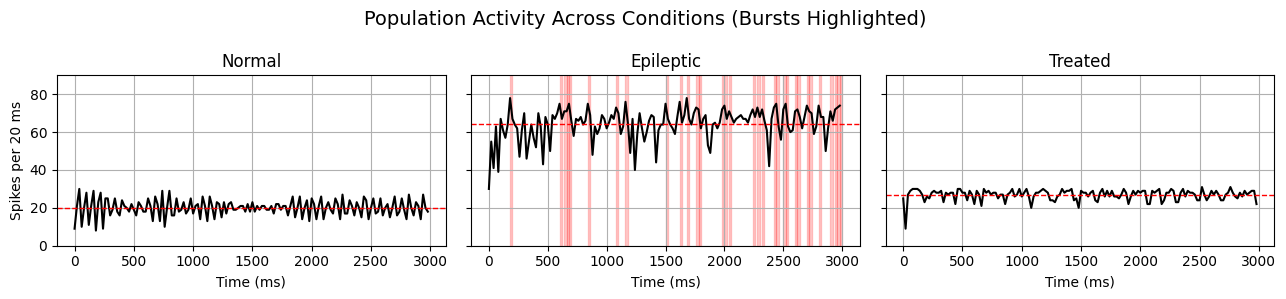

Burst windows detected in 'Epileptic': 32 (threshold = 70 spikes)


In [18]:
plot_population_activity_with_bursts(
    [spikes_normal_net, spikes_epileptic_net, spikes_treated],
    ["Normal", "Epileptic", "Treated"],
    bin_size_ms=20,
    total_time_ms=T,
    burst_threshold=70
)

This visualisation provides an intuitive way to compare the dynamical states of the three networks, highlighting the excessive synchronous activity typical of epileptic states and evaluating the extent to which the simulated treatment suppresses such pathological bursts.